# Frontier research update | NCAA tournament forecasting
**Alvaro Mendizabal · employer-facing ML engineering and research case study**

The strongest retained private post-competition release is **0.1072824 Brier**, compared with the published 2026 winning benchmark of **0.1097454**. The active stretch target is **0.09**. These are retrospective benchmark comparisons, not original competition placements. This notebook publishes aggregate evidence only; it does not reproduce the private forecasting system.

In [1]:
from pathlib import Path
import sys, pandas as pd
root=Path.cwd()
if not (root/'portfolio').is_dir(): root=root.parent
sys.path.insert(0,str(root/'portfolio'))
from frontier_research import load,chart
d=load(); s=d['scores']; c=d['latest_candidate']; m=d['reproduction_matrix']
print({'champion':s['retained_private_champion'],'selected_family':c['selected_family'],'candidate_score':c['candidate_score']})

{'champion': 0.1072824, 'selected_family': 'volume_plus_differences', 'candidate_score': None}


## 1. Competitive boundary
The private research program is numerically below the published 2026 winning benchmark, but the comparison is retrospective. Moving from 0.1072824 to 0.09 still requires a **0.0172824** absolute Brier reduction, so the remaining program prioritizes structural capability gains rather than cosmetic tuning.

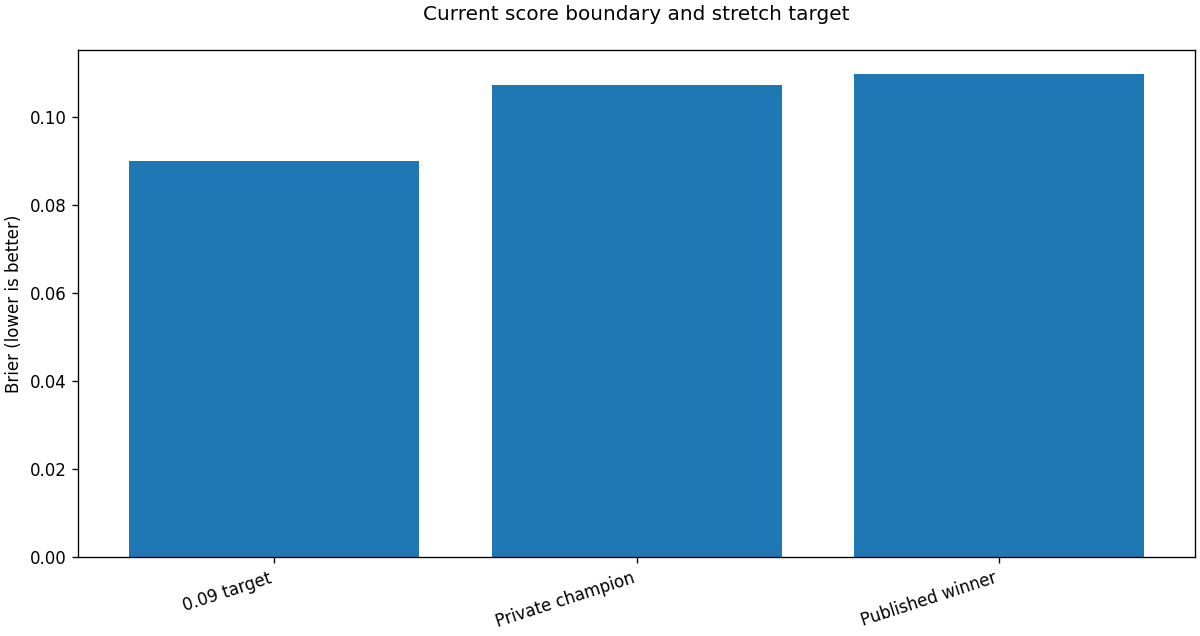

In [2]:
chart('score_boundary','Current score boundary and stretch target',['0.09 target','Private champion','Published winner'],[s['stretch_target'],s['retained_private_champion'],s['published_2026_winner']],'Brier (lower is better)')

## 2. Verified score progression
The public case study previously stopped at 0.1089408. Private research subsequently reached 0.1072824. Scored improvements remain separate from unscored research candidates.

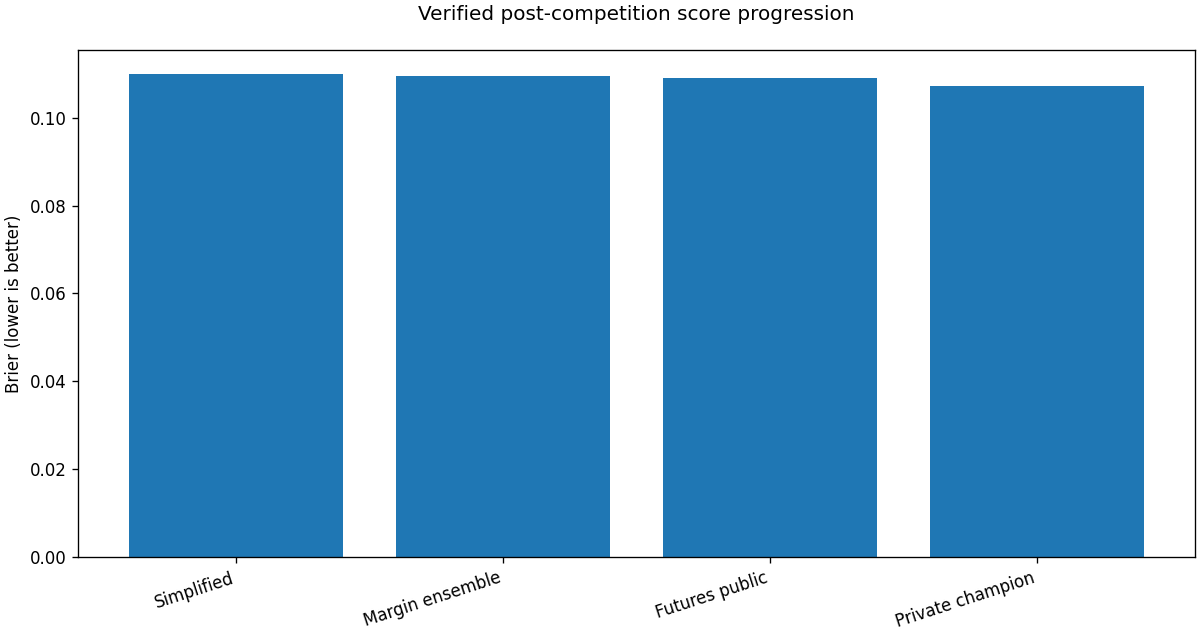

In [3]:
chart('score_progression','Verified post-competition score progression',['Simplified','Margin ensemble','Futures public','Private champion'],[0.1098691,0.1094899,0.1089408,s['retained_private_champion']],'Brier (lower is better)')

## 3. Chronology-safe residual-family selection
The latest candidate adds a capability the prior system did not have: selection among coherent residual representations using season-grouped historical evidence only. Futures inputs do not fit the residual model or choose its representation.

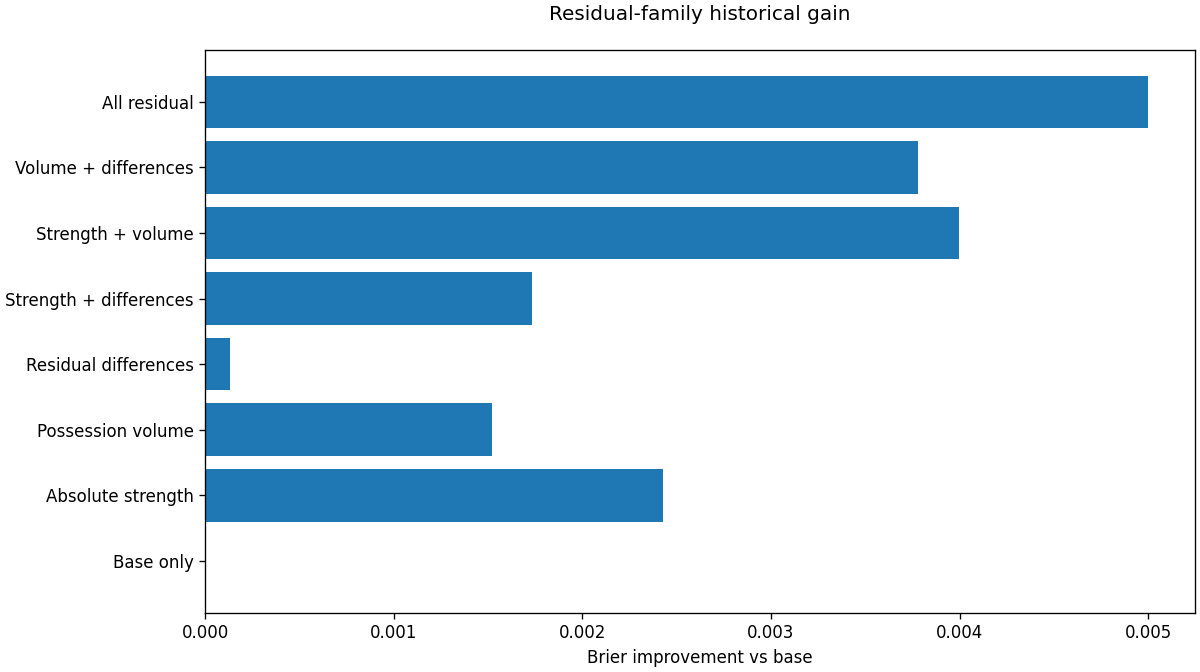

In [4]:
families=['Base only','Absolute strength','Possession volume','Residual differences','Strength + differences','Strength + volume','Volume + differences','All residual']
gains=[0.0,0.002425228446914063,0.0015206271330946985,0.0001331989475467643,0.0017326999586218805,0.003995815372199257,c['selection_gain'],c['all_residual_gain']]
chart('family_gain','Residual-family historical gain',families,gains,'Brier improvement vs base',orientation='h')

## 4. Stability over raw mean gain
The full residual panel had the largest mean gain but violated the predeclared worst-season guardrail. `volume_plus_differences` sacrificed some mean gain for better transfer stability and became the frozen challenger.

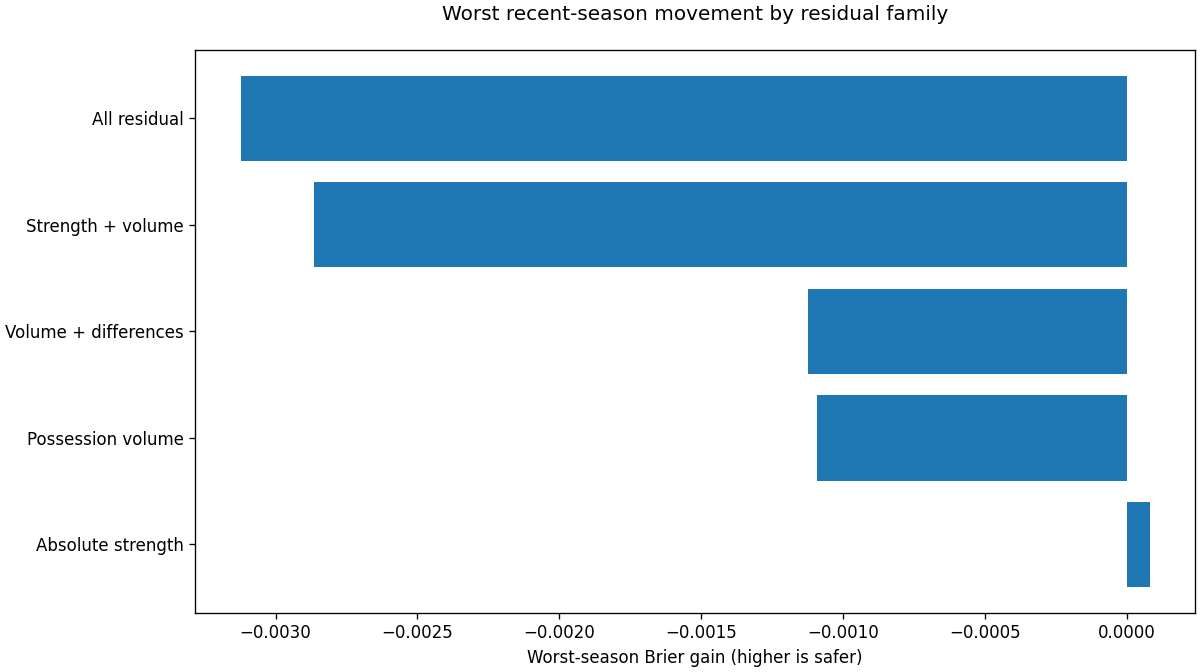

In [5]:
families=['Absolute strength','Possession volume','Volume + differences','Strength + volume','All residual']
worst=[0.00007867586776166835,-0.0010937375543707273,c['worst_season_gain'],-0.002863295102808222,c['all_residual_worst_season_gain']]
chart('family_stability','Worst recent-season movement by residual family',families,worst,'Worst-season Brier gain (higher is safer)',orientation='h')

## 5. Frozen candidate scope
The candidate changes only the approved men’s scope, does not overwrite the scored champion, preserves every women’s row, and made no Kaggle submission in the candidate-build milestone.

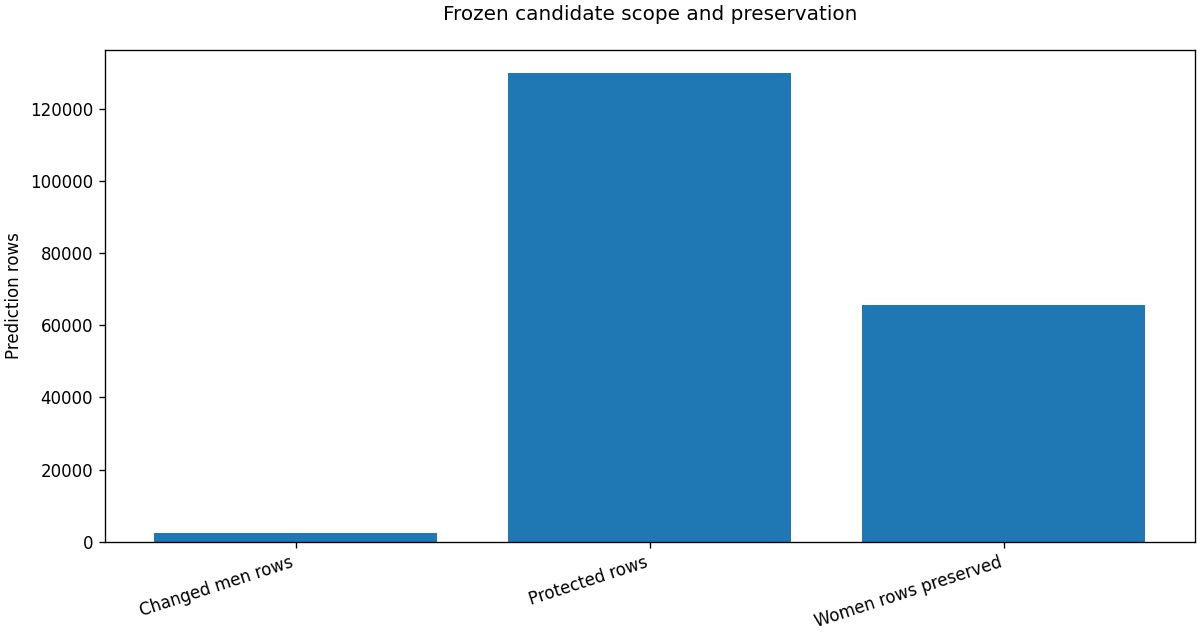

In [6]:
chart('candidate_scope','Frozen candidate scope and preservation',['Changed men rows','Protected rows','Women rows preserved'],[c['changed_mens_rows'],c['protected_rows'],c['women_rows_byte_identical']],'Prediction rows')

## 6. Leading-solution reproduction matrix
A mechanism is not marked recreated merely because it was discussed. The public matrix distinguishes validated adaptations, rejected reproductions, operational prospective infrastructure, provenance-limited adaptations, and missing frontier capabilities.

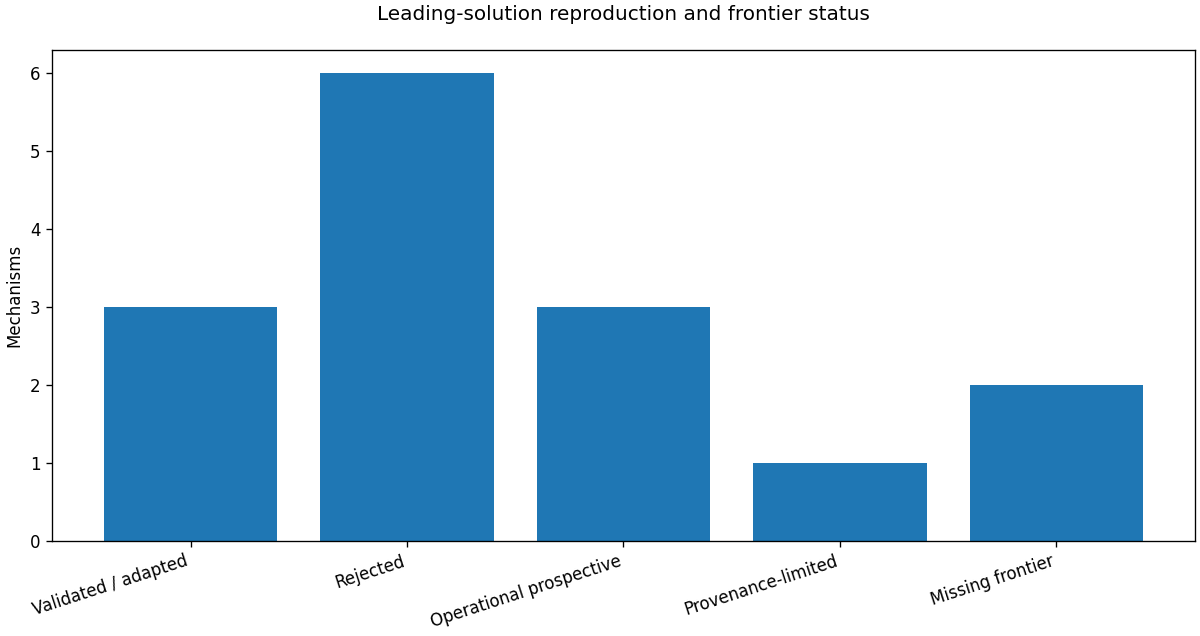

,mechanism,status,public_note
0,Compact statistical reference,ADAPTED_VALIDATED,Adapted and validated as a compact reference s...
1,Score-margin supervision,ADAPTED_VALIDATED,Adapted and validated as a complementary men’s...
2,Residual representation,VALIDATED_HISTORICALLY,Chronology-safe family selection produced a fr...
3,Broad all-residual panel,REJECTED,Rejected because worst-season stability breach...
4,Championship futures layer,ADAPTED_PROVENANCE_LIMITED,Retrospective adaptation; raw pre-deadline 202...
5,Broad / Round-1 market overlays,REJECTED,Rejected in controlled post-competition score ...
6,Fourth-place calibration ideas,REJECTED,Recreated and not retained.
7,Women’s richer margin extension,REJECTED,Historical gain did not transfer to the scored...
8,Tree-leaf probability readout,REJECTED,Did not justify promotion.
9,Sparse ranking-selection variants,REJECTED,Did not become the strongest system.


In [7]:
from collections import Counter
status=Counter(x['status'] for x in m)
groups={'Validated / adapted':sum(status[k] for k in ['ADAPTED_VALIDATED','VALIDATED_HISTORICALLY']),'Rejected':status['REJECTED'],'Operational prospective':sum(status[k] for k in ['OPERATIONAL','OPERATIONAL_GATED','OPERATIONAL_PARTIAL']),'Provenance-limited':status['ADAPTED_PROVENANCE_LIMITED'],'Missing frontier':status['MISSING_FRONTIER']}
chart('frontier_status','Leading-solution reproduction and frontier status',list(groups),list(groups.values()),'Mechanisms')
display(pd.DataFrame(m)[['mechanism','status','public_note']])

## 7. Provenance and next decision
The 2026 market transformations were independently rebuilt, but the original market observations were pinned from a post-competition public artifact rather than independently reconstructed from raw timestamped pre-deadline responses. They remain a fixed retrospective component and are excluded from residual training and selection.

The exact frozen challenger should be scored once. A gain promotes it and triggers error decomposition against the new champion. A non-improvement ends ordinary residual refinement and moves directly to women-specific reconstruction, prospective roster/availability data, and a heterogeneous OOF ensemble. The 2027 raw-first collector and cutoff-freeze design is the stronger prospective test.

In [8]:
assert c['decision']=='CANDIDATE_READY_NOT_SUBMITTED'
assert c['candidate_score'] is None
assert c['known_2026_outcomes_used'] is False
assert c['market_inputs_used_for_selection'] is False and c['market_inputs_used_for_training'] is False
print('FRONTIER_REPORT_COMPLETE — aggregate evidence only; no training or submission')

FRONTIER_REPORT_COMPLETE — aggregate evidence only; no training or submission
